In [1]:
get_ipython().system('pip install pillow_heif split-folders')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 47.1 MB/s eta 0:00:00


In [1]:
from collections import Counter
from PIL import Image, ImageOps, ImageEnhance
from pathlib import Path
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
from pillow_heif import register_heif_opener

import cv2
import os
import shutil
import matplotlib.pyplot as plt
import random
import splitfolders
import torch
import torch.nn as nn
import torch.optim as optim
import time
import seaborn as sns
import numpy as np

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


EfficientNet-B0 |	224 x 224

EfficientNet-B1	| 240 x 240

EfficientNet-B2	| 260 x 260

EfficientNet-B3	| 300 x 300

EfficientNet-B4	| 380 x 380 (common usage, paper implies it is scaled up)

EfficientNet-B5	| 456 x 456

EfficientNet-B6	| 528 x 528 (common usage, paper implies it is scaled up)

EfficientNet-B7	| 600 x 600

In [ ]:
NUMBER_OF_CLASS_SPLITS = 10     # Minimum number of images per class to be included
TARGET_COUNT = 100               # Target number of images per class after augmentation
IMAGE_SIZE = 240

BASE_DRIVE_PATH = '/content/drive/MyDrive/'

DATASET_PATH = os.path.join(BASE_DRIVE_PATH, 'WildSnap-Dataset')
DATASET_PATH_OBJ = Path(DATASET_PATH)

DATASET_PLUS = Path(os.path.join(BASE_DRIVE_PATH, f'WildSnap-Train-{NUMBER_OF_CLASS_SPLITS}plus'))
DATASET_PLUS_SIZE = Path(os.path.join(BASE_DRIVE_PATH, f'WildSnap-Final-{IMAGE_SIZE}'))
DATASET_PLUS_SIZE_SPLIT = Path(os.path.join(BASE_DRIVE_PATH, 'WildSnap-Split-Data'))
DATASET_PLUS_SIZE_SPLIT = os.path.expanduser('~/Goog/WildSnap-Dataset-copy')

if not os.path.exists(DATASET_PLUS): os.makedirs(DATASET_PLUS)
if not os.path.exists(DATASET_PLUS_SIZE): os.makedirs(DATASET_PLUS_SIZE)
if not os.path.exists(DATASET_PLUS_SIZE_SPLIT): os.makedirs(DATASET_PLUS_SIZE_SPLIT)
 
# Default ImageNet normalization values
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]

EXPORT_MODEL = os.path.join(BASE_DRIVE_PATH, 'wildsnap_model.pth')

In [6]:
TRAIN_SPLIT = 80
VAL_SPLIT = 10
TEST_SPLIT = 10

# 1. Exploratory Data Analysis

## Summarize Dataset

In [7]:
def summarize_dataset(path):
    if not os.path.exists(path):
        print("Folder not found. Please check the folder name and try again.")
        return

    report = []
    all_counts = []

    for folder_name in sorted(os.listdir(path)):
        folder_full_path = os.path.join(path, folder_name)

        if os.path.isdir(folder_full_path):
            images = [f for f in os.listdir(folder_full_path)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

            count = len(images)
            report.append((folder_name, count))
            all_counts.append(count)

    if not all_counts:
        print("No image data found.")
        return

    # Calculate Statistic
    total_images = sum(all_counts)
    total_categories = len(report)
    max_val = max(all_counts)
    min_val = min(all_counts)
    avg_val = total_images / total_categories

    # Count number split classes
    passed = sum(1 for c in all_counts if c >= NUMBER_OF_CLASS_SPLITS)
    failed = total_categories - passed

    print("-" * 55)
    print(f"{'Animal (Class)':<25} | {'Count':<10} | {'Status'}")
    print("-" * 55)

    for name, count in report:
        status = "✅ Ready" if count >= NUMBER_OF_CLASS_SPLITS else "⚠️ Too few"
        print(f"{name:<25} | {count:<10} | {status}")

    print("-" * 55)
    print(f"Dataset Statistics:")
    print(f"* Total Categories : {total_categories}")
    print(f"* Total Images     : {total_images}")
    print(f"* Min/Max Images   : {min_val} / {max_val}")
    print(f"* Average Images   : {avg_val:.2f} per class")
    print("-" * 55)
    print(f"Quality Check (Criteria: {NUMBER_OF_CLASS_SPLITS} images):")
    print(f"* Passed Category  : {passed} ✅")
    print(f"* Failed Category  : {failed} ❌")
    print("-" * 55)

In [ ]:
summarize_dataset(DATASET_PATH)

-------------------------------------------------------
Animal (Class)            | Count      | Status
-------------------------------------------------------
African_Pygmy_Dormouse    | 4          | ⚠️ Too few
Albino_Siamese_Crocodile  | 25         | ✅ Ready
Ball_Python               | 35         | ✅ Ready
Ball_Python copy          | 35         | ✅ Ready
Black-headed_Caique       | 29         | ✅ Ready
Blue-and-gold_Macaw       | 63         | ✅ Ready
Blue-tongued_Skink        | 23         | ✅ Ready
Budapest_Pigeon           | 22         | ✅ Ready
Budgerigar                | 14         | ✅ Ready
Burmese_Python            | 25         | ✅ Ready
Cockatiel                 | 8          | ⚠️ Too few
Cuviers_Dwarf_Caiman      | 22         | ✅ Ready
Golden_Burmese_Python     | 19         | ✅ Ready
Gouldian_Finch            | 64         | ✅ Ready
Green-cheeked_Conure      | 23         | ✅ Ready
Grey_Crowned_Crane        | 43         | ✅ Ready
Grey_Parrot               | 32         | ✅ Ready
I

## Summariza Image Size

In [8]:
def summarize_file_extensions(base_path):
    base_path = Path(base_path)
    ext_counter = Counter()

    for class_dir in base_path.iterdir():
        if class_dir.is_dir():
            for file_path in class_dir.iterdir():
                if file_path.is_file():
                    ext = file_path.suffix.lower()
                    if ext:
                        ext_counter[ext] += 1

    return ext_counter

In [ ]:
summarize_file_extensions(DATASET_PATH)

Counter({'.jpg': 888, '.jpeg': 304, '.png': 39, '.heic': 163})

## Corrupted Images

In [9]:
def find_broken_images(base_path):
    base_path = Path(base_path)
    broken = []

    for class_dir in base_path.iterdir():
        if class_dir.is_dir():
            for img_path in class_dir.iterdir():
                try:
                    Image.open(img_path).verify()
                except Exception:
                    broken.append(img_path)

    return broken


In [ ]:
find_broken_images(DATASET_PATH)

[PosixPath('/content/drive/MyDrive/WildSnap-Dataset/Zebra_Finch/IMG_5996.HEIC'),
 PosixPath('/content/drive/MyDrive/WildSnap-Dataset/Zebra_Finch/IMG_5997.HEIC'),
 PosixPath('/content/drive/MyDrive/WildSnap-Dataset/Zebra_Finch/IMG_5995.HEIC'),
 PosixPath('/content/drive/MyDrive/WildSnap-Dataset/Zebra_Finch/IMG_5998.HEIC'),
 PosixPath('/content/drive/MyDrive/WildSnap-Dataset/Zebra_Finch/IMG_5992.HEIC'),
 PosixPath('/content/drive/MyDrive/WildSnap-Dataset/Black-headed_Caique/IMG_5999.HEIC'),
 PosixPath('/content/drive/MyDrive/WildSnap-Dataset/Black-headed_Caique/IMG_6004.HEIC'),
 PosixPath('/content/drive/MyDrive/WildSnap-Dataset/Black-headed_Caique/IMG_6003.HEIC'),
 PosixPath('/content/drive/MyDrive/WildSnap-Dataset/Black-headed_Caique/IMG_6002.HEIC'),
 PosixPath('/content/drive/MyDrive/WildSnap-Dataset/Grey_Parrot/IMG_6292.HEIC'),
 PosixPath('/content/drive/MyDrive/WildSnap-Dataset/Grey_Parrot/IMG_6287.HEIC'),
 PosixPath('/content/drive/MyDrive/WildSnap-Dataset/Grey_Parrot/IMG_6284.HEIC

## Visual EDA

In [10]:
# Display random samples from random classes
def visual_eda(base_path, num_samples=5):
    base_path = Path(base_path).expanduser()

    # Randomly select 3 subdirectories (classes)
    subdirs = [d for d in base_path.iterdir() if d.is_dir() and not d.name.startswith('.')]

    if not subdirs:
        print("No subdirectories found in the specified path.")
        return

    selected_classes = random.sample(subdirs, min(3, len(subdirs)))

    # Create subplots to show images
    fig, axes = plt.subplots(len(selected_classes), num_samples, figsize=(15, 10))

    if len(selected_classes) == 1:
        axes = axes.reshape(1, -1)

    for i, class_path in enumerate(selected_classes):
        images = [img for img in class_path.iterdir()
                  if img.suffix.lower() in ['.jpg', '.jpeg', '.png']
                  and not img.name.startswith('.')]

        if not images:
            print(f"No images found in folder: {class_path.name}")
            continue

        samples = random.sample(images, min(num_samples, len(images)))

        for j, img_path in enumerate(samples):
            img = Image.open(img_path)
            axes[i, j].imshow(img)
            axes[i, j].set_title(f"{class_path.name}", fontsize=10)
            axes[i, j].axis('off')

    plt.tight_layout()
    plt.show()

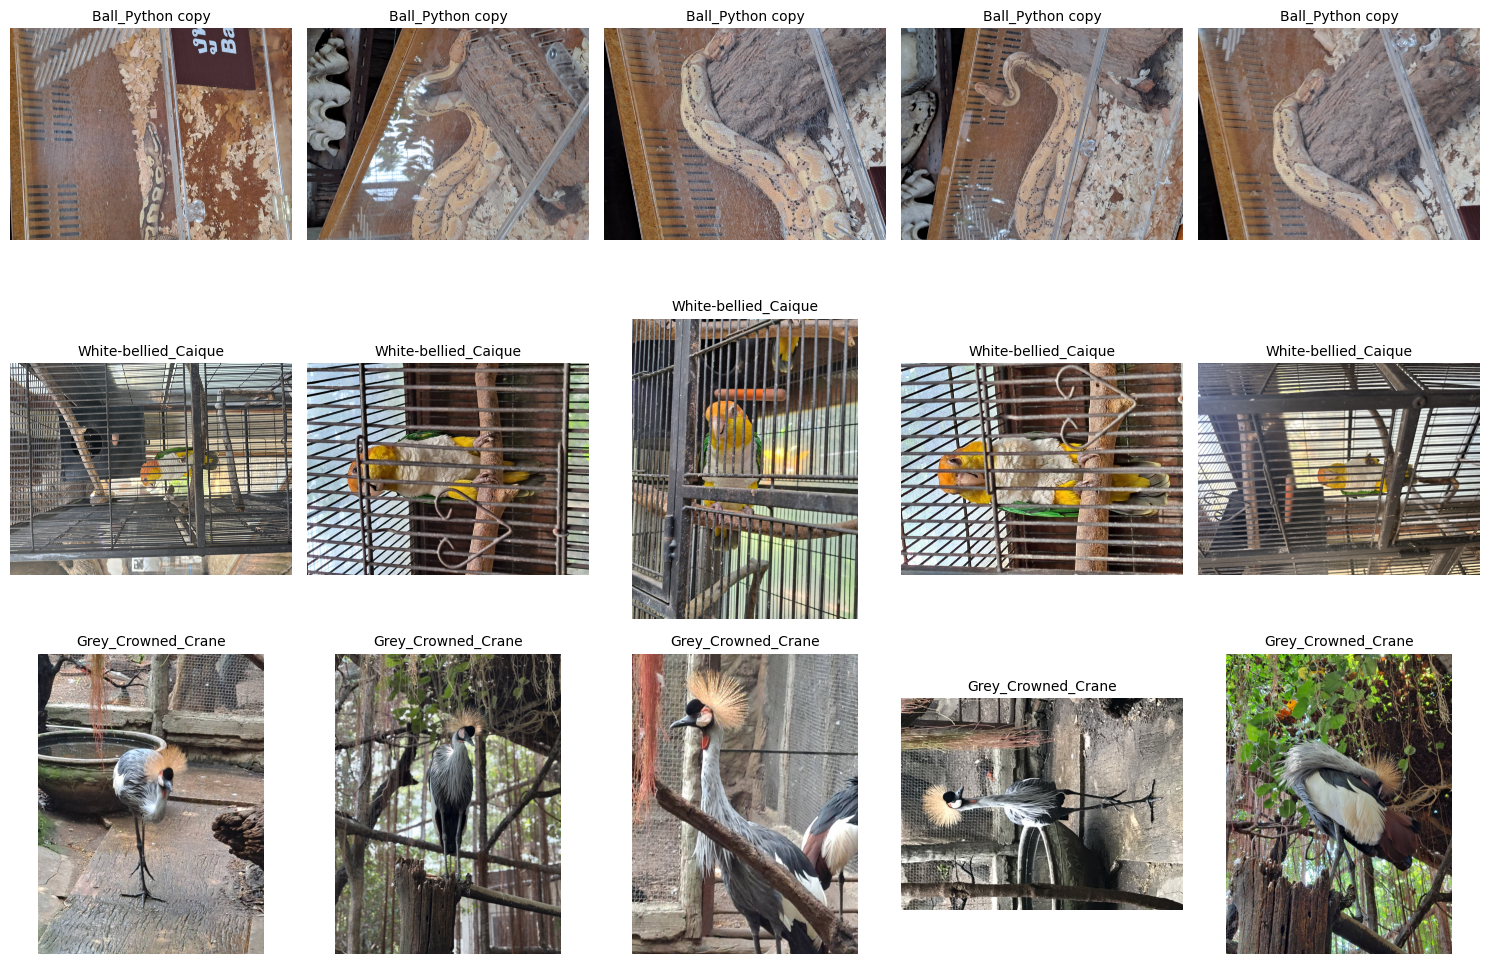

In [ ]:
visual_eda(DATASET_PATH)

## Image Size Summary

In [11]:
def image_size_summary(base_path):
    base_path = Path(base_path)
    size_counter = Counter()
    total_images = 0

    for img_path in base_path.rglob("*"):
        if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue

        try:
            with Image.open(img_path) as img:
                size_counter[f"{img.width}x{img.height}"] += 1
                total_images += 1
        except Exception:
            continue

    # Print summary
    print("Image Size Summary:\n")
    for size, count in size_counter.most_common():
        print(f"{size} : {count} images")

    print(f"\nTotal image files counted: {total_images}")

    return size_counter

In [ ]:
image_size_summary(DATASET_PATH)

Image Size Summary:

4624x3468 : 705 images
4032x3024 : 183 images
1108x1477 : 159 images
5712x4284 : 138 images
3024x4032 : 53 images
1477x1108 : 5 images
4284x5712 : 4 images
794x854 : 3 images
456x654 : 3 images
724x600 : 1 images
750x584 : 1 images
544x490 : 1 images
610x702 : 1 images
520x636 : 1 images
560x540 : 1 images
436x456 : 1 images
400x522 : 1 images
424x412 : 1 images
450x408 : 1 images
460x640 : 1 images
526x604 : 1 images
256x300 : 1 images
406x432 : 1 images
544x530 : 1 images
566x600 : 1 images
870x934 : 1 images
1034x1568 : 1 images
1198x1562 : 1 images
1006x1346 : 1 images
1010x1344 : 1 images
656x530 : 1 images
1002x1350 : 1 images
822x680 : 1 images
990x1324 : 1 images
996x1334 : 1 images
738x988 : 1 images
626x920 : 1 images
680x854 : 1 images
594x872 : 1 images
850x1200 : 1 images
690x590 : 1 images
704x540 : 1 images

Total image files counted: 1286


Counter({'4624x3468': 705,
         '1108x1477': 159,
         '3024x4032': 53,
         '4032x3024': 183,
         '4284x5712': 4,
         '5712x4284': 138,
         '1477x1108': 5,
         '724x600': 1,
         '750x584': 1,
         '794x854': 3,
         '544x490': 1,
         '610x702': 1,
         '520x636': 1,
         '560x540': 1,
         '436x456': 1,
         '400x522': 1,
         '424x412': 1,
         '450x408': 1,
         '456x654': 3,
         '460x640': 1,
         '526x604': 1,
         '256x300': 1,
         '406x432': 1,
         '544x530': 1,
         '566x600': 1,
         '870x934': 1,
         '1034x1568': 1,
         '1198x1562': 1,
         '1006x1346': 1,
         '1010x1344': 1,
         '656x530': 1,
         '1002x1350': 1,
         '822x680': 1,
         '990x1324': 1,
         '996x1334': 1,
         '738x988': 1,
         '626x920': 1,
         '680x854': 1,
         '594x872': 1,
         '850x1200': 1,
         '690x590': 1,
         '704x540': 1

# 2. Data Filtering / Selection

## Quantity Filtering

In [12]:
def filter_and_prepare_dataset(src, dest):
    if not dest.exists():
        dest.mkdir(parents=True)
        print(f"Create a New Folder for Experiment: {dest}")

    print(f"Start filtering animals with images >= {NUMBER_OF_CLASS_SPLITS}...")
    print("-" * 50)

    selected_classes = 0
    total_images_copied = 0

    # Loop through all animal folders in the source
    for folder in sorted(src.iterdir()):
        # Skip Mac system files (.DS_Store) and other non-directory files
        if folder.is_dir() and not folder.name.startswith('.'):
            # Count only image files
            images = [f for f in folder.iterdir()
                      if f.suffix.lower() in ['.jpg', '.jpeg', '.png']
                      and not f.name.startswith('.')]

            count = len(images)

            if count >= NUMBER_OF_CLASS_SPLITS:
                dest_folder = dest / folder.name

                # If the destination folder already exists, remove it and create a new one (to avoid duplicate data)
                if dest_folder.exists():
                    shutil.rmtree(dest_folder)

                shutil.copytree(folder, dest_folder)

                print(f"✅ {folder.name:<25} | {count:>3} Images [Copied]")
                selected_classes += 1
                total_images_copied += count
            else:
                # If it doesn't meet the criteria, show that it is skipped
                print(f"❌ {folder.name:<25} | {count:>3} Images [Below threshold - Skipped]")

    print("-" * 50)
    print(f"- Summary: Selected {selected_classes} classes")
    print(f"- Total images ready for training: {total_images_copied}")
    print(f"- Data located at: {dest}")

In [ ]:
filter_and_prepare_dataset(DATASET_PATH_OBJ, DATASET_PLUS)

Start filtering animals with images >= 10...
--------------------------------------------------
❌ African_Pygmy_Dormouse    |   4 Images [Below threshold - Skipped]
✅ Albino_Siamese_Crocodile  |  25 Images [Copied]
✅ Ball_Python               |  35 Images [Copied]
✅ Ball_Python copy          |  35 Images [Copied]
✅ Black-headed_Caique       |  29 Images [Copied]
✅ Blue-and-gold_Macaw       |  63 Images [Copied]
✅ Blue-tongued_Skink        |  23 Images [Copied]
✅ Budapest_Pigeon           |  22 Images [Copied]
✅ Budgerigar                |  14 Images [Copied]
✅ Burmese_Python            |  25 Images [Copied]
❌ Cockatiel                 |   8 Images [Below threshold - Skipped]
✅ Cuviers_Dwarf_Caiman      |  22 Images [Copied]
✅ Golden_Burmese_Python     |  19 Images [Copied]
✅ Gouldian_Finch            |  64 Images [Copied]
✅ Green-cheeked_Conure      |  23 Images [Copied]
✅ Grey_Crowned_Crane        |  43 Images [Copied]
✅ Grey_Parrot               |  32 Images [Copied]
✅ Iguana        

In [ ]:
summarize_dataset(DATASET_PLUS)

-------------------------------------------------------
Animal (Class)            | Count      | Status
-------------------------------------------------------
Albino_Siamese_Crocodile  | 25         | ✅ Ready
Ball_Python               | 35         | ✅ Ready
Ball_Python copy          | 35         | ✅ Ready
Black-headed_Caique       | 29         | ✅ Ready
Blue-and-gold_Macaw       | 63         | ✅ Ready
Blue-tongued_Skink        | 23         | ✅ Ready
Budapest_Pigeon           | 22         | ✅ Ready
Budgerigar                | 14         | ✅ Ready
Burmese_Python            | 25         | ✅ Ready
Cuviers_Dwarf_Caiman      | 22         | ✅ Ready
Golden_Burmese_Python     | 19         | ✅ Ready
Gouldian_Finch            | 64         | ✅ Ready
Green-cheeked_Conure      | 23         | ✅ Ready
Grey_Crowned_Crane        | 43         | ✅ Ready
Grey_Parrot               | 32         | ✅ Ready
Iguana                    | 73         | ✅ Ready
Madagascar_Giant_Day_Gecko | 86         | ✅ Ready
Meerka

In [ ]:
summarize_file_extensions(DATASET_PLUS)

Counter({'.jpg': 819, '.jpeg': 301, '.heic': 130, '.png': 39})

In [ ]:
find_broken_images(DATASET_PLUS)

[PosixPath('/content/drive/MyDrive/WildSnap-Train-40plus/Gouldian_Finch/IMG_6009.HEIC'),
 PosixPath('/content/drive/MyDrive/WildSnap-Train-40plus/Gouldian_Finch/IMG_6183.HEIC'),
 PosixPath('/content/drive/MyDrive/WildSnap-Train-40plus/Gouldian_Finch/IMG_6007.HEIC'),
 PosixPath('/content/drive/MyDrive/WildSnap-Train-40plus/Gouldian_Finch/IMG_6010.HEIC'),
 PosixPath('/content/drive/MyDrive/WildSnap-Train-40plus/Gouldian_Finch/IMG_6008.HEIC'),
 PosixPath('/content/drive/MyDrive/WildSnap-Train-40plus/Gouldian_Finch/IMG_6011.HEIC'),
 PosixPath('/content/drive/MyDrive/WildSnap-Train-40plus/Gouldian_Finch/IMG_6182.HEIC'),
 PosixPath('/content/drive/MyDrive/WildSnap-Train-40plus/Gouldian_Finch/IMG_6181.HEIC'),
 PosixPath('/content/drive/MyDrive/WildSnap-Train-40plus/Gouldian_Finch/IMG_6176.HEIC'),
 PosixPath('/content/drive/MyDrive/WildSnap-Train-40plus/Gouldian_Finch/IMG_6016.HEIC'),
 PosixPath('/content/drive/MyDrive/WildSnap-Train-40plus/Gouldian_Finch/IMG_6020.HEIC'),
 PosixPath('/content/

# 3. Data Preprocessing

# Convert Image

In [13]:
register_heif_opener()

In [14]:
def convert_heic_to_jpg(folder_path):
    base_path = Path(folder_path).expanduser().resolve()

    if not base_path.exists():
        print(f"Folder not found: {base_path}")
        return

    files = [f for f in base_path.rglob("*") if f.suffix.lower() in ['.heic', '.heif']]

    if not files:
        print(f"Searching in: {base_path}")
        print("No .heic files found in this folder or its subfolders")

        for i, f in enumerate(base_path.rglob("*")):
            if i > 5: break
            print(f"- {f.name} (suffix: {f.suffix})")
        return

    print(f"Found a total of {len(files)} HEIC files, starting conversion...")

    for file in files:
        try:
            image = Image.open(file)

            target_path = file.with_suffix('.jpg')

            image.convert("RGB").save(target_path, "JPEG", quality=95)
            print(f"Converted successfully: {file.relative_to(base_path)} -> .jpg")

            os.remove(file)

        except Exception as e:
            print(f"❌ Error occurred with file {file.name}: {e}")

    print("\nConversion completed!")

In [ ]:
convert_heic_to_jpg(DATASET_PLUS)

Found a total of 130 HEIC files, starting conversion...
Converted successfully: Ball_Python/IMG_6127 (1).HEIC -> .jpg
Converted successfully: Ball_Python/IMG_6127.HEIC -> .jpg
Converted successfully: Ball_Python/IMG_6306.HEIC -> .jpg
Converted successfully: Ball_Python/IMG_6305.HEIC -> .jpg
Converted successfully: Ball_Python/IMG_6126.HEIC -> .jpg
Converted successfully: Ball_Python/IMG_6125.HEIC -> .jpg
Converted successfully: Ball_Python/IMG_6307.HEIC -> .jpg
Converted successfully: Ball_Python/IMG_6122 (1).HEIC -> .jpg
Converted successfully: Ball_Python/IMG_6122.HEIC -> .jpg
Converted successfully: Ball_Python/IMG_6124.HEIC -> .jpg
Converted successfully: Ball_Python/IMG_6310.HEIC -> .jpg
Converted successfully: Ball_Python/IMG_6123.HEIC -> .jpg
Converted successfully: Ball_Python/IMG_6309.HEIC -> .jpg
Converted successfully: Ball_Python/IMG_6121.HEIC -> .jpg
Converted successfully: Ball_Python/IMG_6119.HEIC -> .jpg
Converted successfully: Ball_Python/IMG_6308.HEIC -> .jpg
Converte

In [ ]:
summarize_file_extensions(DATASET_PLUS)

Counter({'.jpg': 949, '.jpeg': 301, '.png': 39})

## Resize Image to 240 x 240

In [17]:
image_size_summary(DATASET_PLUS)

Image Size Summary:

4624x3468 : 612 images
4032x3024 : 176 images
1108x1477 : 138 images
5712x4284 : 136 images
3024x4032 : 136 images
4284x5712 : 50 images
456x654 : 3 images
794x854 : 3 images
1477x1108 : 2 images
526x604 : 1 images
870x934 : 1 images
724x600 : 1 images
1034x1568 : 1 images
1198x1562 : 1 images
1006x1346 : 1 images
1010x1344 : 1 images
656x530 : 1 images
1002x1350 : 1 images
822x680 : 1 images
990x1324 : 1 images
996x1334 : 1 images
738x988 : 1 images
626x920 : 1 images
680x854 : 1 images
594x872 : 1 images
850x1200 : 1 images
256x300 : 1 images
406x432 : 1 images
544x530 : 1 images
566x600 : 1 images
460x640 : 1 images
690x590 : 1 images
704x540 : 1 images
750x584 : 1 images
544x490 : 1 images
610x702 : 1 images
520x636 : 1 images
560x540 : 1 images
436x456 : 1 images
400x522 : 1 images
424x412 : 1 images
450x408 : 1 images

Total image files counted: 1289


Counter({'4624x3468': 612,
         '1108x1477': 138,
         '5712x4284': 136,
         '4032x3024': 176,
         '4284x5712': 50,
         '3024x4032': 136,
         '526x604': 1,
         '870x934': 1,
         '1477x1108': 2,
         '724x600': 1,
         '1034x1568': 1,
         '1198x1562': 1,
         '1006x1346': 1,
         '1010x1344': 1,
         '656x530': 1,
         '1002x1350': 1,
         '822x680': 1,
         '990x1324': 1,
         '996x1334': 1,
         '738x988': 1,
         '626x920': 1,
         '680x854': 1,
         '594x872': 1,
         '850x1200': 1,
         '256x300': 1,
         '406x432': 1,
         '544x530': 1,
         '566x600': 1,
         '456x654': 3,
         '460x640': 1,
         '690x590': 1,
         '704x540': 1,
         '750x584': 1,
         '794x854': 3,
         '544x490': 1,
         '610x702': 1,
         '520x636': 1,
         '560x540': 1,
         '436x456': 1,
         '400x522': 1,
         '424x412': 1,
         '450x408':

In [20]:
def resize_and_pad(img_path, output_path, size=214):
    try:
        with Image.open(img_path) as img:
            # Convert to RGB (to handle PNG with Alpha channel or CMYK files)
            img = img.convert('RGB')

            # Calculate aspect ratio to resize the longest side to 214
            img.thumbnail((size, size), Image.Resampling.LANCZOS)

            # Fill with black background image of size 214x214
            new_img = Image.new("RGB", (size, size), (0, 0, 0))

            # Place the image in the center of the background
            left = (size - img.width) // 2
            top = (size - img.height) // 2
            new_img.paste(img, (left, top))

            new_img.save(output_path, "JPEG", quality=95)
    except Exception as e:
        print(f"❌ Can't process file {img_path.name}: {e}")

In [22]:
print(f"Defining image size to {IMAGE_SIZE}x{IMAGE_SIZE} with black background...")

if not DATASET_PLUS_SIZE.exists():
    DATASET_PLUS_SIZE.mkdir(parents=True)

for class_folder in sorted(DATASET_PLUS.iterdir()):
    if class_folder.is_dir() and not class_folder.name.startswith('.'):
        output_class_dir = DATASET_PLUS_SIZE / class_folder.name
        output_class_dir.mkdir(exist_ok=True)

        print(f"Processing: {class_folder.name}...")

        for img_file in class_folder.iterdir():
            if img_file.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                output_file_path = output_class_dir / f"{img_file.stem}.jpg"
                resize_and_pad(img_file, output_file_path, size=IMAGE_SIZE)

print(f"\n Finished! All images are saved at: {DATASET_PLUS_SIZE}")

Defining image size to 240x240 with black background...
Processing: Albino_Siamese_Crocodile...
Processing: Ball_Python...
Processing: Black-headed_Caique...
Processing: Blue-and-gold_Macaw...
Processing: Blue-tongued_Skink...
Processing: Budapest_Pigeon...
Processing: Budgerigar...
Processing: Burmese_Python...
Processing: Cuviers_Dwarf_Caiman...
Processing: Golden_Burmese_Python...
Processing: Gouldian_Finch...
Processing: Green-cheeked_Conure...
Processing: Grey_Crowned_Crane...
Processing: Grey_Parrot...
Processing: Iguana...
Processing: Madagascar_Giant_Day_Gecko...
Processing: Meerkat...
Processing: Muscovy_Duck...
Processing: Pallas_Squirrel...
Processing: Scarlet_Macaw...
Processing: Siamese_Cat...
Processing: Silkie_Chicken...
Processing: Squirrel_Monkey...
Processing: Sulcata_Tortoise...
Processing: Sulphur-crested_Cockatoo...
Processing: Unknow...
Processing: White-bellied_Caique...
Processing: Yellow_Ring-necked_Parakeet...
Processing: Zebra_Finch...

 Finished! All images 

In [23]:
image_size_summary(DATASET_PLUS_SIZE)

Image Size Summary:

240x240 : 1289 images

Total image files counted: 1289


Counter({'240x240': 1289})

# 4. Data Splitting

In [24]:
def split_dataset(input_folder, output_folder):
    if not output_folder.exists():
        output_folder.mkdir(parents=True)

    print(f"Splitting dataset with Train/Val/Test ratio of {TRAIN_SPLIT}/{VAL_SPLIT}/{TEST_SPLIT}...")

    splitfolders.ratio(input_folder, output=output_folder,
                       seed=1337, ratio=(TRAIN_SPLIT/100, VAL_SPLIT/100, TEST_SPLIT/100),
                       group_prefix=None, move=False)

    print("Dataset split completed.")

In [25]:
split_dataset(DATASET_PLUS_SIZE, DATASET_PLUS_SIZE_SPLIT)

Splitting dataset with Train/Val/Test ratio of 80/10/10...


Copying files: 1289 files [00:19, 66.71 files/s]

Dataset split completed.


# 5. Data Augmentation

In [ ]:
def augment_image(img):
    # Randomly flip image horizontally
    if random.random() > 0.5:
        img = ImageOps.mirror(img)

    # Randomly rotate image (-15 to 15 degrees)
    angle = random.randint(-15, 15)
    img = img.rotate(angle, fillcolor=(0,0,0)) # Rotate and fill black border

    # Randomly adjust brightness (0.8 to 1.2)
    enhancer = ImageEnhance.Brightness(img)
    img = enhancer.enhance(random.uniform(0.8, 1.2))

    return img

In [ ]:
print(f"Starting Augmentation to ensure each class has at least {TARGET_COUNT} images...\n")

for class_folder in sorted(DATASET_PLUS_SIZE.iterdir()):
    if class_folder.is_dir() and not class_folder.name.startswith('.'):
        # Get the list of existing images
        images = [f for f in class_folder.iterdir() if f.suffix.lower() in ['.jpg', '.jpeg', '.png']]
        current_count = len(images)

        if current_count < TARGET_COUNT:
            num_to_add = TARGET_COUNT - current_count
            print(f"{class_folder.name}: has {current_count} images, adding {num_to_add} more...")

            for i in range(num_to_add):
                # Randomly select one original image to augment
                source_img_path = random.choice(images)
                with Image.open(source_img_path) as img:
                    augmented_img = augment_image(img)

                    new_name = f"aug_{i}_{source_img_path.name}"
                    augmented_img.save(class_folder / new_name, "JPEG", quality=95)
        else:
            print(f"✅ {class_folder.name}: has enough images ({current_count} images)")

print(f"\nDone! Now every class in {DATASET_PLUS_SIZE} has at least {TARGET_COUNT} images.")

In [ ]:
summarize_dataset(DATASET_PLUS_SIZE)

# 6. Data Loader

## Tensor Conversion & Normalization

In [ ]:
class ApplyCLAHE(object):
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size

    def __call__(self, img):
        img_array = np.array(img.convert('RGB'))

        lab = cv2.cvtColor(img_array, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)

        clahe = cv2.createCLAHE(clipLimit=self.clip_limit, tileGridSize=self.tile_grid_size)
        cl = clahe.apply(l)

        limg = cv2.merge((cl, a, b))
        final_img = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)

        return Image.fromarray(final_img)

In [ ]:
def define_normalization_transforms():
    data_transforms = {
        'train': transforms.Compose([
            ApplyCLAHE(clip_limit=3.0),
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
            transforms.RandomGrayscale(p=0.1),
            transforms.ToTensor(),
            transforms.Normalize(NORM_MEAN, NORM_STD)
        ]),
        'val': transforms.Compose([
            ApplyCLAHE(clip_limit=3.0),
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
            transforms.RandomGrayscale(p=0.1),
            transforms.ToTensor(),
            transforms.Normalize(NORM_MEAN, NORM_STD)
        ]),
    }

    print("✅ Normalization transforms defined successfully")
    return data_transforms

In [ ]:
data_transforms = define_normalization_transforms()
data_transforms

In [ ]:
# Create Dataset with transforms (including Normalization)
image_datasets = {
    x: datasets.ImageFolder(DATASET_PLUS_SIZE_SPLIT / x, data_transforms[x])
    for x in ['train', 'val']
}

# 2. Create DataLoader (data conveyor belt)
dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=16, shuffle=True)
    for x in ['train', 'val']
}

In [ ]:
# Analyze dataset sizes and classes
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

print(f"Summary of normalized data:")
print(f"- Number of Classes: {len(class_names)} types")
print(f"- Training images: {dataset_sizes['train']} images")
print(f"- Validation images: {dataset_sizes['val']} images")

# 7. Define Model

In [ ]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"🚀 Using Device: {device}")

# Load pre-trained EfficientNet-B0 model
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# Adjust the classifier head to match the number of your animal classes
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, len(class_names))

# Move the model to GPU/CPU
model = model.to(device)

# 4. Define Loss function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"✅ Model defined successfully, ready to classify {len(class_names)} animal types")

# 8. Start Training

In [ ]:
def train_model(model, criterion, optimizer, num_epochs=10):
    since = time.time()

    # Store training history
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                # Forward Pass (let AI predict)
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward Pass (fine-tune only during training)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.cpu().float() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

    time_elapsed = time.time() - since
    print(f'\nTraining completed in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    return model, history

In [ ]:
# Start training (try starting with 10-15 epochs first)
trained_model, train_history = train_model(model, criterion, optimizer, num_epochs=15)

# 9. Result Testing

## Learning Curves Result

In [ ]:
def plot_history(history):
    acc = history['train_acc']
    val_acc = history['val_acc']
    loss = history['train_loss']
    val_loss = history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    # Accuracy graph
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    # Loss graph
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    plt.show()

In [ ]:
plot_history(train_history)

## Confusion Matrix

In [ ]:
def show_confusion_matrix(model, dataloader):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

In [ ]:
show_confusion_matrix(trained_model, dataloaders['val'])

## Test Model

In [ ]:
test_dataset = datasets.ImageFolder(DATASET_PLUS_SIZE_SPLIT / 'test', data_transforms['val'])

test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Number of images in the final test set: {len(test_dataset)} images")

In [ ]:
def evaluate_test_set(model, dataloader):
    model.eval()
    running_corrects = 0

    print("Starting test evaluation...")

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            running_corrects += torch.sum(preds == labels.data)

    test_acc = running_corrects.cpu().float() / len(dataloader.dataset)
    print(f"\nTest Set Accuracy (unseen data): {test_acc:.4f} ({test_acc*100:.2f}%)")
    return test_acc

In [ ]:
final_test_acc = evaluate_test_set(trained_model, test_dataloader)

In [ ]:
def evaluate_test_set_internet(model, image_path):
    img = Image.open(image_path).convert('RGB')
    # Use the same transform as validation (Resize + Normalize)
    transform = data_transforms['val']
    img_tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        prob = torch.nn.functional.softmax(output[0], dim=0)
        conf, pred = torch.max(prob, 0)

    plt.imshow(img)
    plt.title(f"Prediction: {class_names[pred]} ({conf*100:.2f}%)")
    plt.axis('off')
    plt.show()

## Test with Animal in the Model

In [ ]:
test_image = Path("~/Downloads/iguana01.jpeg").expanduser()
evaluate_test_set_internet(trained_model, test_image)

In [ ]:
test_image = Path("~/Downloads/duck01.jpeg").expanduser()
evaluate_test_set_internet(trained_model, test_image)

In [ ]:
test_image = Path("~/Downloads/meerkat01.webp").expanduser()
evaluate_test_set_internet(trained_model, test_image)

## Test with unknow Animal in Model

In [ ]:
test_image = Path("~/Downloads/unknow-bird.jpg").expanduser()
evaluate_test_set_internet(trained_model, test_image)

In [ ]:
test_image = Path("~/Downloads/fish.jpg").expanduser()
evaluate_test_set_internet(trained_model, test_image)

# 10. Save Model

In [ ]:
# Save the trained model
torch.save(trained_model.state_dict(), EXPORT_MODEL)
print(f"Saved the trained model as {EXPORT_MODEL}")